# Count each

### Load

In [7]:
from pathlib import Path
import json
import re

RESULTS_DIR = Path("all_results")
ARXIV_ID_PATTERN = re.compile(r'^\d{4}\.\d{4,5}(v\d+)?$')

arxiv_paths: dict[str, list[str]] = {}
hf_paths: dict[str, list[str]] = {}
unknown_keys: list[str] = []

for json_path in RESULTS_DIR.glob('*.json'):
    key = json_path.stem
    with json_path.open() as handle:
        payload = json.load(handle)

    path_value = None
    for value in payload.values():
        if isinstance(value, dict) and 'path' in value:
            path_value = value['path']
            break

    if path_value is None:
        continue

    if ARXIV_ID_PATTERN.fullmatch(key):
        arxiv_paths[key] = path_value
    elif any(char.isalpha() for char in key):
        hf_paths[key] = path_value
    else:
        unknown_keys.append(key)

print(f'Loaded {len(arxiv_paths)} arXiv paths and {len(hf_paths)} HF model paths.')
if unknown_keys:
    print(f'WARNING: {len(unknown_keys)} filenames were not classified: {unknown_keys[:5]}')
if len(arxiv_paths) != len(hf_paths):
    print('Counts differ between arXiv and HF entries')
else:
    print('Counts are equal')


Loaded 4288 arXiv paths and 4300 HF model paths.
Counts differ between arXiv and HF entries


The other ones seem to be "philosophical/theoretical foundations of artificial intelligence"
this is of lenght 64, but when gtp predicts it it raises an error saying

!! BAD REQUEST ERROR!!
Error code: 400 - {'error': {'message': "Invalid 'response_format.json_schema.name': string too long. Expected a string with maximum length 64, but got a string with length 70 instead.", 'type': 'invalid_request_error', 'param': 'response_format.json_schema.name', 'code': 'string_above_max_length'}}
skipping paper and filling zeros in score
key: 2208.14037

### collect

In [2]:
from metadata_schemas.acm_ccs import CCS_HIERARCHY

ccs_strings = str(CCS_HIERARCHY).split("'")[1::2]
ccs_counts_hf = {s:0 for s in ccs_strings}
ccs_counts_ax = ccs_counts_hf.copy()

In [3]:
for key in hf_paths:
    for term in hf_paths[key]:
        try:
            ccs_counts_hf[term] += 1
        except KeyError:
            print(key, hf_paths[key])

for key in arxiv_paths:
    for term in arxiv_paths[key]:
        try:
            ccs_counts_ax[term] += 1
        except KeyError:
            print(key, hf_paths[key])


In [4]:
print("Hf\tArxiv\n")
for term in ccs_strings:
    hfc, axc = ccs_counts_hf[term], ccs_counts_ax[term]
    if hfc+axc>5:
        if min(hfc, axc) / max(hfc, axc) < 0.5:
            if axc < hfc:
                print(hfc, "\t", axc, "\t",term)

print("")
for term in ccs_strings:
    hfc, axc = ccs_counts_hf[term], ccs_counts_ax[term]
    if hfc+axc>5:
        if min(hfc, axc) / max(hfc, axc) < 0.5:
            if hfc < axc:
                print(hfc, "\t", axc, "\t",term)

Hf	Arxiv

1832 	 692 	 Natural language processing
681 	 161 	 Natural language generation
165 	 17 	 Speech recognition
131 	 40 	 Lexical semantics
270 	 69 	 Language resources
52 	 8 	 Description logics
7 	 2 	 Ranking
270 	 67 	 Reinforcement learning
142 	 44 	 Sequential decision making
50 	 15 	 Inverse reinforcement learning
16 	 0 	 Apprenticeship learning
49 	 4 	 Multi-agent reinforcement learning
12 	 4 	 Adversarial learning
34 	 9 	 Learning from demonstrations
10 	 0 	 Learning from critiques
5 	 1 	 Maximum a posteriori modeling
25 	 10 	 Bayesian network models
125 	 28 	 Regularization
19 	 9 	 Other

9 	 37 	 Probabilistic reasoning
2 	 10 	 Temporal reasoning
0 	 11 	 Cognitive robotics
2 	 11 	 Spatial and physical reasoning
3 	 104 	 Planning and scheduling
2 	 8 	 Planning for deterministic actions
0 	 28 	 Planning under uncertainty
0 	 10 	 Multi-agent planning
1 	 42 	 Planning with abstraction and generalization
4 	 10 	 Evolutionary robotics
42 	 113 	 Sea

# Find time stamps

In [12]:
from dataset_loader import Arxiv_HF_datasets
ahd = Arxiv_HF_datasets()
ahd.prepare()
hf_df, arx_df = ahd.sample_subsets(100)

/home/sondre/profile/llmdap/profiler/dataset_loader.py:448: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  self.arx = self.arx[self.arx["bin"]>=bin_range[0]][self.arx["bin"]<=bin_range[1]]


In [13]:
hf_df = hf_df.set_index("modelId")

# Compile to single results files

In [14]:
hf_df = hf_df.drop(["card", "tags", "pipeline_tag", "bin"], axis=1)
hf_df["predicted_tag"] = ""

In [15]:
arx_df = arx_df.drop(["title", "abstract", "authors_parsed", "bin"], axis=1)
arx_df["predicted_tag"] = ""

In [16]:
for modelid in hf_df.index:
    try:
        hf_df.loc[modelid, "predicted_tag"]= str(hf_paths[modelid.replace("/","__")])
    except:
        print(modelid)
        hf_df.loc[modelid, "predicted_tag"]= str(["Computing methodologies","Artificial intelligence","Philosophical/theoretical foundations of artificial intelligence"])

In [17]:
for paperid in arx_df.index:
    try:
        arx_df.loc[paperid, "predicted_tag"]= str(arxiv_paths[paperid])
    except KeyError:
        print(paperid)
        arx_df.loc[paperid, "predicted_tag"]= str(["Computing methodologies","Artificial intelligence","Philosophical/theoretical foundations of artificial intelligence"])

2209.11764
2301.12569
2302.09067
2305.18475
2310.20363
2312.07637
2401.04854
2412.13145
2501.15740
2507.01833
2508.08293
2509.02089


In [23]:
hf_df.to_csv("hf_trends.csv.bz2")
arx_df.to_csv("arxiv_trends.csv.bz2")

# plots

In [1]:
from matplotlib import pyplot as plt
import pandas as pd
from metadata_schemas.acm_ccs import CCS_HIERARCHY

ccs_strings = str(CCS_HIERARCHY).split("'")[1::2]


In [2]:
hf_df=pd.read_csv("hf_trends.csv.bz2", index_col=0)
arx_df=pd.read_csv("arxiv_trends.csv.bz2", index_col=0)

hf_df["createdAt"] = pd.to_datetime(hf_df["createdAt"])
arx_df["submission_date"] = pd.to_datetime(arx_df["submission_date"])


In [3]:
def plot_term(term):
    


    hf_dates = hf_df[hf_df["predicted_tag"].str.contains("'"+term+"'")]["createdAt"]
    arx_dates = arx_df[arx_df["predicted_tag"].str.contains("'"+term+"'")]["submission_date"]

    if len(arx_dates)+len(hf_dates)<50:
        return
    plt.hist(arx_dates, bins=20, label="arx")
    plt.hist(hf_dates, bins=20, alpha=0.6, label="HF")
    plt.title(term)
    plt.legend()
    plt.show()

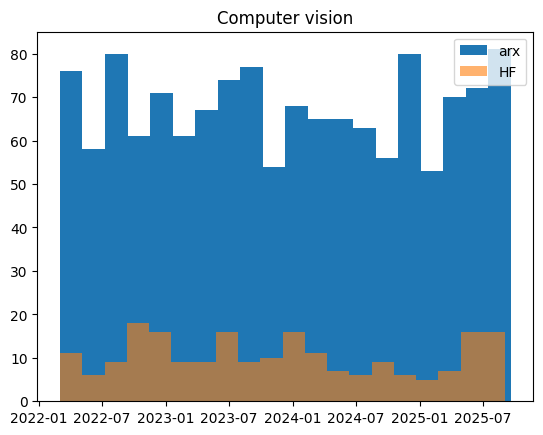

In [4]:
plot_term(term = "Computer vision")

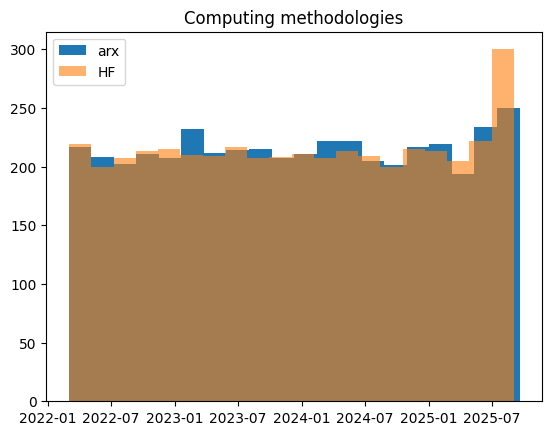

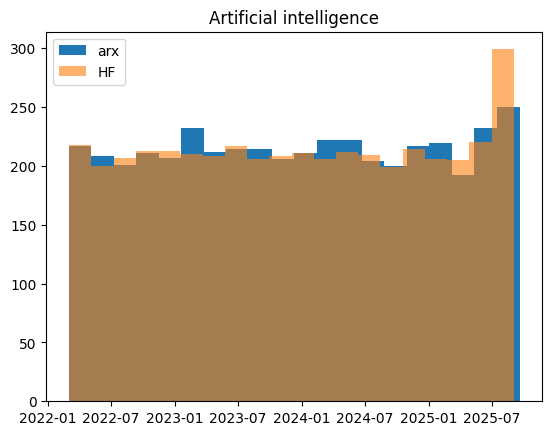

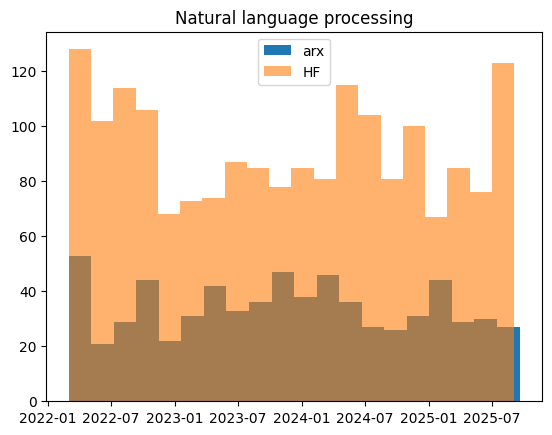

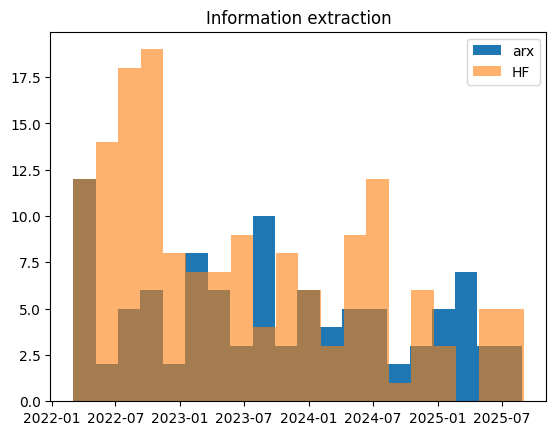

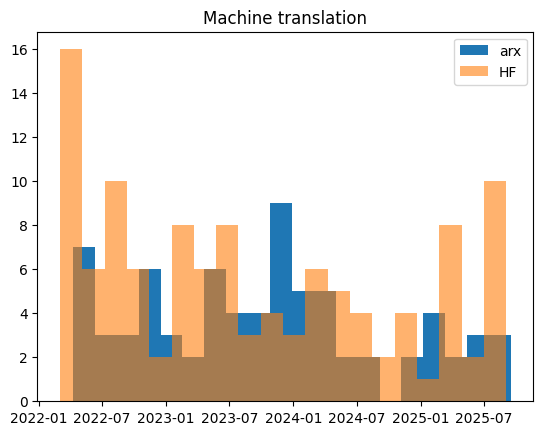

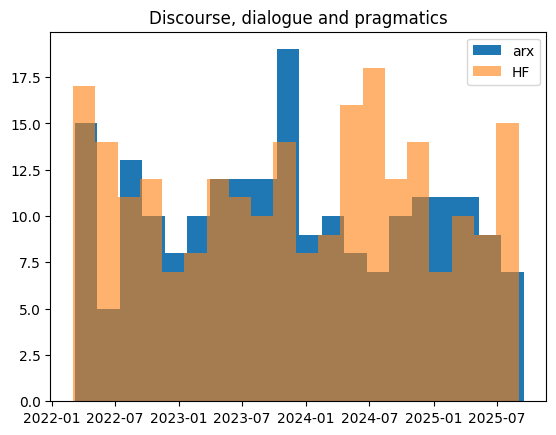

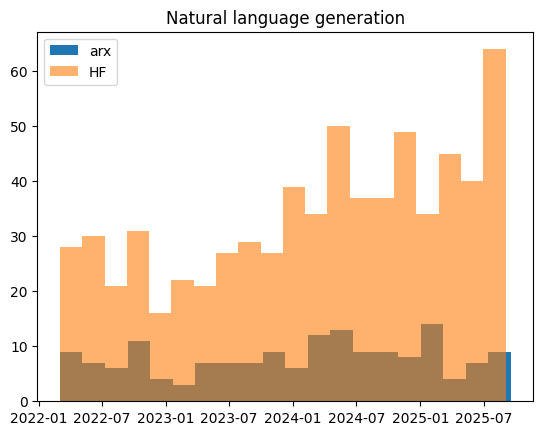

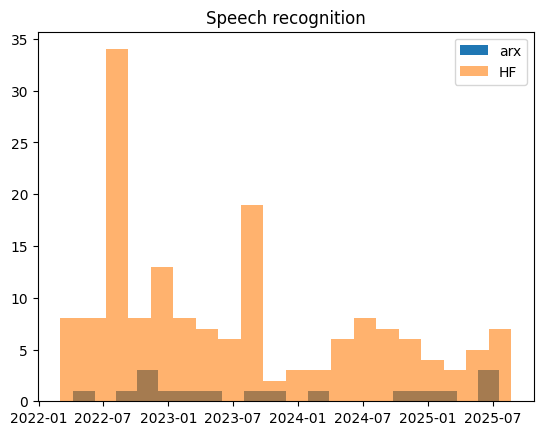

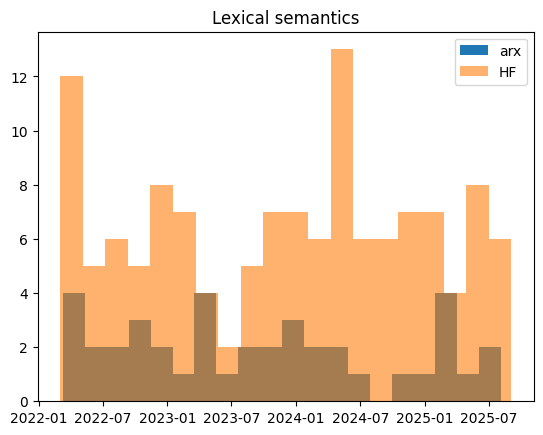

In [5]:
for term in ccs_strings[:10]:
    plot_term(term)
